# Understanding Experimental Data pt 2

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random

- Now we understand the process of having experimental data and trying to make inference, extract insights or test a theorical model of the features that we observe

- Remember that our goal is to find a model that fits our experimental data while is allow us to explain phenomena and make predictions aobut it with new data samples

- Now , data usually is not clean, we have to account for uncertaintity in measurements or observatons 

- Soemtimes we have theorical knowledge that can lead us in how the relationship should be... but in most cases we dont'! So we are goin to try to find the best model 

- One model that we could use is **Linear Regression** that helps us to find the best polynomy of degree n that fits the data points, by minimizing the least squares function (the deviations with respect to the predictions squared). Given the example of a sipmle linear model, with two parameters to estiamte, the problem can be summarized in this picture:

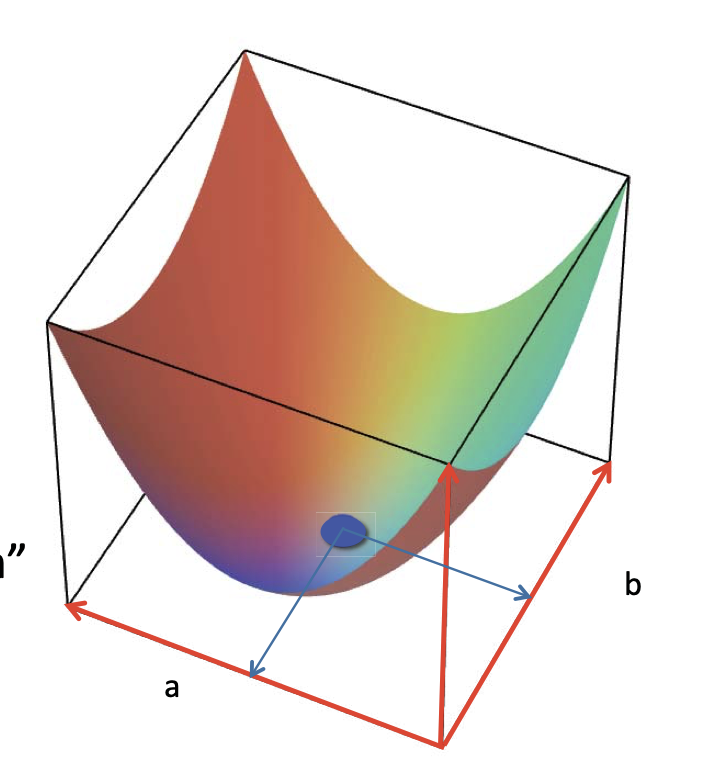

# Functions

In [4]:
def getData(fileName):
    """
    This can be totally done wtih pandas, but lets stick to the orignal material
    it would be a great exercise to use and keep learning python
    """

    dataFile = open(fileName, "r")
    distances = []
    masses = []
    dataFile.readline()  # descard header
    for line in dataFile:
        d, m = line.split()
        distances.append(float(d))
        masses.append(float(m))

    dataFile.close()
    return (masses, distances)


def labelPlot():
    plt.title("Measured Displacement of Spring")
    plt.xlabel("|Force| (Newtons)")
    plt.ylabel("Distance (meters)")


def plotData(fileName):
    xVals, yVals = getData(fileName)
    xVals = np.array(xVals)
    yVals = np.array(yVals)
    xVals = xVals * 9.81  # acc due to gravity
    plt.plot(xVals, yVals, "bo", label="Measured displacements")
    plt.show()


def fitData(fileName):
    xVals, yVals = getData(fileName)
    xVals = np.array(xVals)
    yVals = np.array(yVals)
    xVals = xVals * 9.81  # get force
    plt.plot(xVals, yVals, "bo", label="measured points")
    labelPlot()
    a, b = np.polyfit(xVals, yVals, 1)  # linear regression with a polynomy of degree 1
    estYvals = a * np.array(xVals) + b
    print(f"a = {a} \n b = {b}")
    plt.plot(xVals, estYvals, "r", label=f"Linear fit, k = {round(1/a, 5)} ")
    plt.legend()
    plt.show()


def fitData1(fileName):
    xVals, yVals = getData(fileName)
    xVals = np.array(xVals)
    yVals = np.array(yVals)
    xVals = xVals * 9.81
    plt.plot(xVals, yVals, "bo", label="Measured points")
    labelPlot()
    model = np.polyfit(xVals, yVals, 1)
    estyVals = np.polyval(model, xVals)
    plt.plot(xVals, estyVals, "r", label=f"Linear fit, k = {round(1/model[0],5)}")
    plt.legend(loc="best")


def fitData2(fileName):
    xVals, yVals = getData(fileName)
    xVals = np.array(xVals[:-6])
    yVals = np.array(yVals[:-6])
    xVals = xVals * 9.81
    plt.plot(xVals, yVals, "bo", label="Measured points")
    labelPlot()
    model = np.polyfit(xVals, yVals, 1)
    estyVals = np.polyval(model, xVals)
    plt.plot(xVals, estyVals, "r", label=f"Linear fit, k = {round(1/model[0],5)}")
    plt.legend(loc="best")


## compare models:


def aveMeanSquareError(data, predicted):
    error = 0.0
    for i in range(len(data)):
        error += (data[i] - predicted[i]) ** 2

    return error / len(data)


def rSquared(observed, predicted):
    squaredError = ((predicted - observed) ** 2).sum()
    meanSquaredError = squaredError / len(observed)

    return 1 - meanSquaredError / np.var(observed)


def genFits(xVals, yVals, degrees):
    models = []
    for d in degrees:
        model = np.polyfit(xVals, yVals, d)
        models.append(model)

    return models


def testFits(models, degrees, xVals, yVals, title):
    plt.plot(xVals, yVals, "o", label="Data")

    for i in range(len(models)):
        estyVals = np.polyval(models[i], xVals)

        r2 = rSquared(yVals, estyVals)

        plt.plot(
            xVals, estyVals, label=f"Fit of degree {degrees[i]}, R2 = {round(r2, 5)}"
        )

    plt.legend(loc="best")
    plt.title(title)
    plt.show()

# Recap of our previous problem

- In the previous lecture we attempeted to build amodel to fit our mystery data, finding that the quadratic model was the best fit

- But... can we get a better fit? what if we try higher polynomials to this data? Comparing them with the **coeficient of determination**

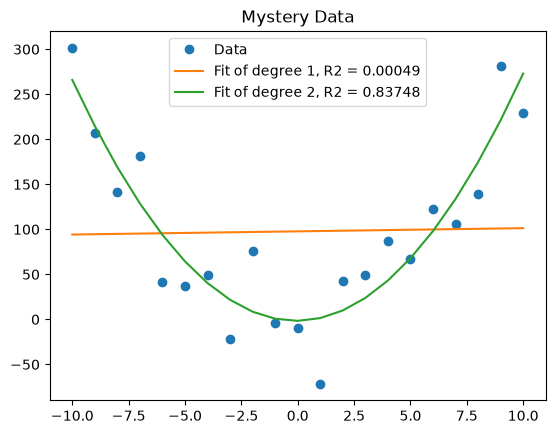

In [6]:
xVals, yVals = getData("../data/mysteryData.txt")
degrees = (1, 2)
models = genFits(xVals, yVals, degrees)
testFits(models, degrees, xVals, yVals, "Mystery Data")

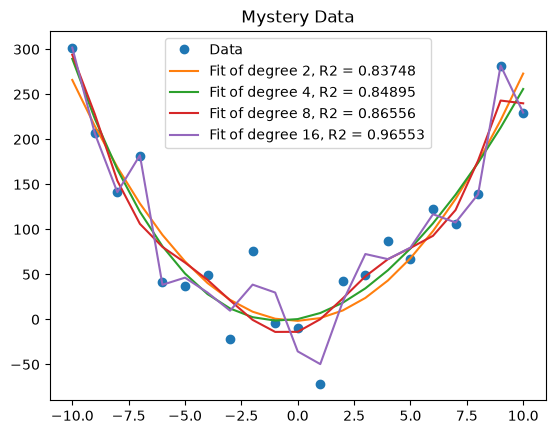

In [8]:
# Comparing higher order fits:

degrees = (2, 4, 8, 16)

models = genFits(xVals, yVals, degrees)
models = genFits(xVals, yVals, degrees)
testFits(models, degrees, xVals, yVals, "Mystery Data")

- We notice that the model with the best R2 is the one with degree 16! With 96% of the variance explained by the model, but is this a good model?

- We realize that the data that we are using to generate this data.. is just a parabola function with a noisy term! Nothing more than that, if that is the case, why the 16 degree polynomial was the best model?  

In [16]:
def genNoisyParabolicData(a, b, c, xVals, FName):
    yVals = []
    for x in xVals:
        theoreticalVal = a * x**2 + b * x + c
        yVals.append(theoreticalVal + random.gauss(0, 35))

    f = open(FName, "w")
    f.write("x        y\n")
    for i in range(len(yVals)):
        f.write(str(yVals[i]) + " " + str(xVals[i]) + "\n")

    f.close


# these were the parameters for generating tthat data


xVals = range(-10, 11, 1)
a, b, c = 3.0, 0.0, 0.0
degrees = (2, 4, 8, 16)

random.seed(0)
genNoisyParabolicData(a, b, c, xVals, "../data/Dataset 1.txt")
genNoisyParabolicData(a, b, c, xVals, "../data/Dataset 2.txt")

So now, what is happening? This is called **over fitting** the process was generated by a 2 degree polynomio, that was the generiting process behind this!

But still, the 16 degree model has a better R2... but is because is learning the noise! That noise that we introduced!! 

But again, often we don't exactly know that ist the generating process of our data, what could be the best way to know when are we overffiting our models?? THe answer is **cross validation**

Lets generate two different datasets with the same parameters, we will train a model with one of those and "test" that model with the other data! Why? because we want to know if our models were able to **generalize**

Lets eavluate our models using the data they were trained on

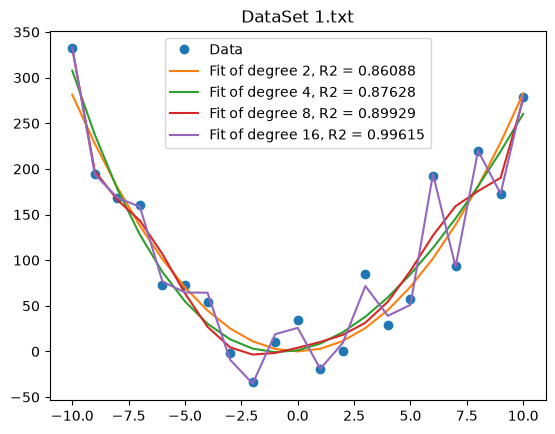

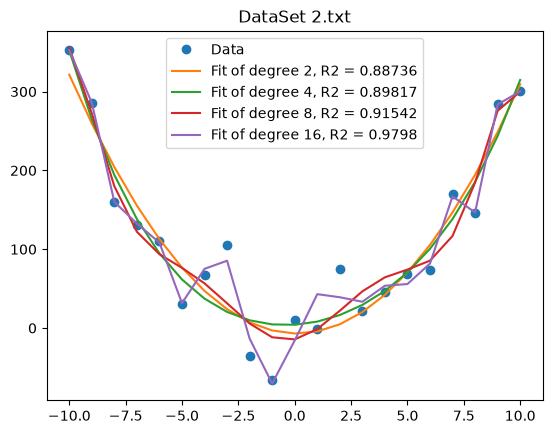

In [21]:
xVals1, yVals1 = getData("../data/Dataset 1.txt")
models1 = genFits(xVals1, yVals1, degrees)
testFits(models1, degrees, xVals1, yVals1, "DataSet 1.txt")
plt.show()

xVals2, yVals2 = getData("../data/Dataset 2.txt")
models2 = genFits(xVals2, yVals2, degrees)
testFits(models2, degrees, xVals2, yVals2, "DataSet 2.txt")
plt.show()

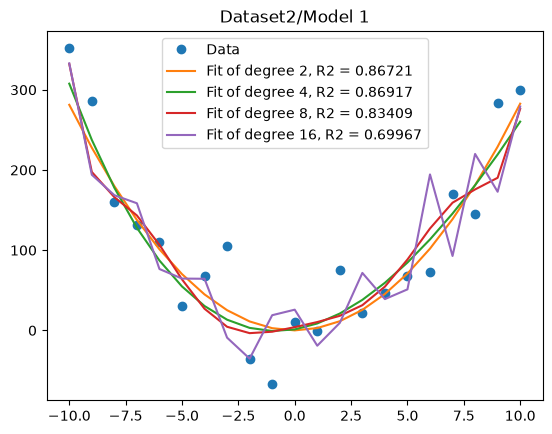

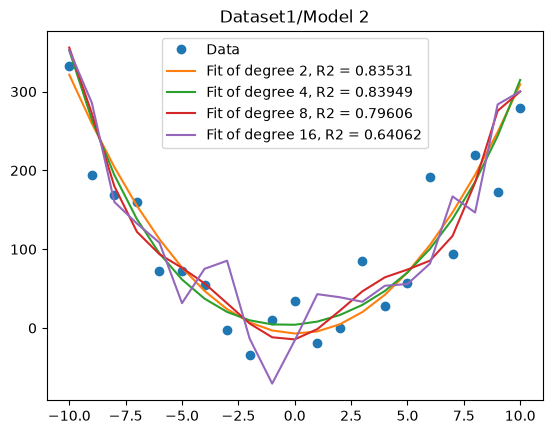

In [22]:
testFits(models1, degrees, xVals2, yVals2, "Dataset2/Model 1")
plt.show()
testFits(models2, degrees, xVals1, yVals1, "Dataset1/Model 2")
plt.show()

And that is the true! The model that has generalized the best was the quadratic! Look how the 16-degree model decreased its R2! now it only represents the 64% of the total variation, wihle the quadratic remained around 83%

In early days of Machine Learning there are a lot of horror stories about data scientist bragging about their perfect models , they thought that their models wonderfully predict an effect... while it was just overfitting!



# Testing with simple data

THis experiment raises a great question: Having a complex model is always better? 

The asnwer is... if the data would be prefect, the degree of the model does not matter! We could add more and more terms but if the data is perfect, those terms would be ignore... so the focus is on the **noise**. With noise data sets we incur in the risk of model it! 

Lets check it by using a second degree polynomio to fit a straight line

 a = -0.0, b = 1.0 , c = 0.0
R-sqaured = 1.0


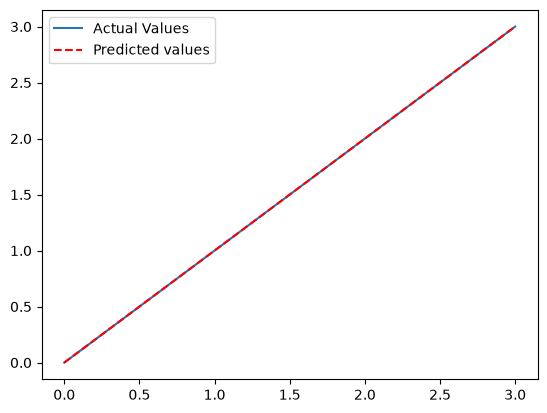

In [23]:
xVals = (0, 1, 2, 3)
yVals = xVals

plt.plot(xVals, yVals, label="Actual Values")

a, b, c = np.polyfit(xVals, yVals, 2)  # LETS USE A SECOND degree

print(f" a = {round(a,4)}, b = {round(b,4)} , c = {round(c,4)}")

estyVals = np.polyval((a, b, c), xVals)
plt.plot(xVals, estyVals, "r--", label="Predicted values")

print(f"R-sqaured = {rSquared(yVals, estyVals)}")
plt.legend(loc="best")
plt.show()

- Notice how it did not matter the degree! The linear regression ignored totally the c term!

- Lets predict nother point using this model and notice how is still perefct

R-Squared = 1.0 


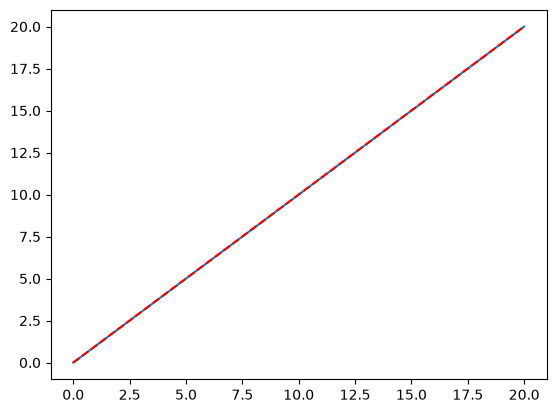

In [26]:
xVals = xVals + (20,)
yVals = xVals
plt.plot(xVals, yVals, label="True data")
estyVals = np.polyval((a, b, c), xVals)
plt.plot(xVals, estyVals, "r--", label="Predicted Values")
print(f"R-Squared = {rSquared(yVals, estyVals)} ")

# Now lets simulate a small Measurement error

And now lets see what would happen if we add some "noise" , we would notice how the thrid term (of the quadradic polynomial now is not zero!)


 a = 0.025, b = 0.955 , c = 0.005
R-sqaured = 0.9999057936881771


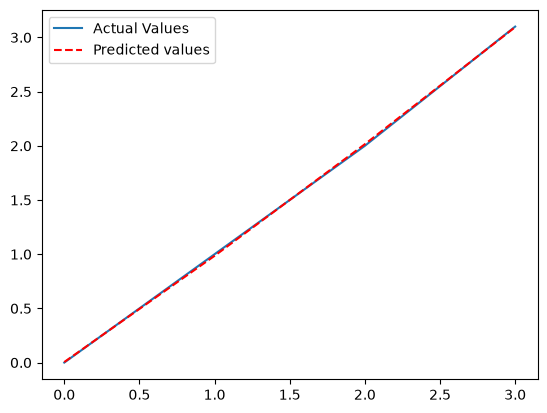

In [ ]:
xVals = (0, 1, 2, 3)
yVals = (0, 1, 2, 3.1)  # just a .1 of deviation!
plt.plot(xVals, yVals, label="Actual Values")

a, b, c = np.polyfit(xVals, yVals, 2)  # LETS USE A SECOND degree

print(f" a = {round(a,4)}, b = {round(b,4)} , c = {round(c,4)}")

estyVals = np.polyval((a, b, c), xVals)
plt.plot(xVals, estyVals, "r--", label="Predicted values")

print(f"R-sqaured = {rSquared(yVals, estyVals)}")
plt.legend(loc="best")

plt.show()

(0, 1, 2, 3, 20)
R-Squared = 0.7026164813486435 


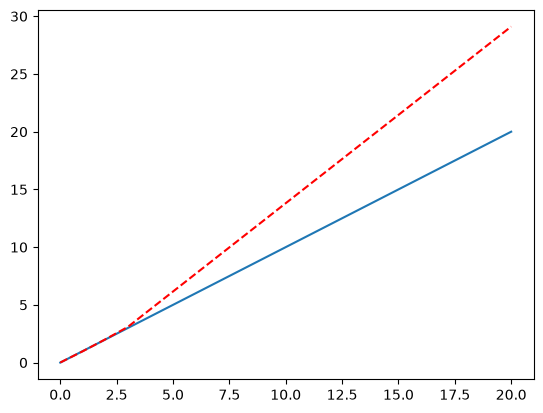

In [52]:
# And now we wnat to see what would happen if we predict unseen data points:
xVals = (0, 1, 2, 3)
yVals = (0, 1, 2, 3.1)  # just a .1 of deviation!
xVals = xVals + (20,)
yVals = xVals
plt.plot(xVals, yVals, label="True data")
estyVals = np.polyval((a, b, c), xVals)
plt.plot(xVals, estyVals, "r--", label="Predicted Values")
print(xVals)
print(f"R-Squared = {rSquared(yVals, estyVals)} ")

Amazing, just a small variation , a little bit of noise produce this effects, a 3% in a data point caused a huge problem! 

And.. how can we fix this? **By using a simpler model!**

R-Squared = 0.9994347621290627 


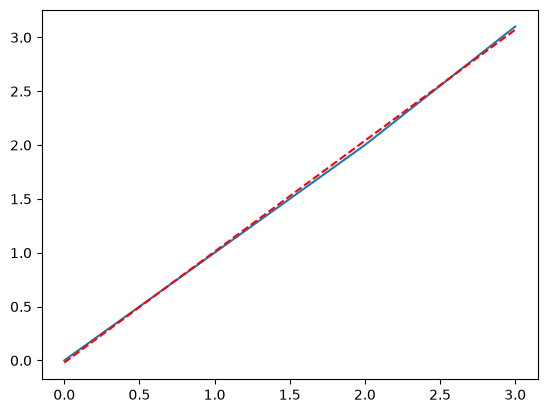

In [53]:
xVals = (0, 1, 2, 3)
yVals = (0, 1, 2, 3.1)  # just a .1 of deviation!
model = np.polyfit(xVals, yVals, 1)
estyVals = np.polyval(model, xVals)
plt.plot(xVals, yVals, label="True data")
plt.plot(xVals, estyVals, "r--", label="Predicted Values")
print(f"R-Squared = {rSquared(yVals, estyVals)} ")

The simpler model is a lot better! But there is a tradeoff... we saw how with a parabola data a straight line was horrible!

So we want to find an inssuficient complex model that will explain the data well without overfitting. A model that is simplest as possible but still explains the data

Now, how far we want to go? This could be standard way of doing it:

1. Fit a lienar model a sipmlest one, 
2. Increase the degree of the model and keep repeating it until you find a point in which a model does a good job does good on the training data and predicting new data, and after it stars to fall up gives you a point where to stop
3. Evaluate in a validation fold the results! We could use a Leave-one-out cross vlidation, a k-fold if we hvae more data or reapeated random sampling

# An example: Temperature by year

In [55]:
class tempDatum:
    def __init__(self, s):
        info = s.split(",")

        self.high = float(info[1])
        self.year = int(info[2][0:4])

    def getHigh(self):
        return self.high

    def getYear(self):
        return self.year


def getTempData():
    inFile = open("../data/temperatures.csv")

    data = []
    for l in inFile:
        data.append(tempDatum(l))

    return data


def getYearlyMeans(data):
    years = {}
    for d in data:
        try:
            years[d.getYear()].append(d.getHigh())

        except:
            years[d.getYear()] = [d.getHigh()]

    for y in years:
        years[y] = sum(years[y]) / len(years[y])

    return years

Text(0.5, 1.0, 'Select U.S. cities')

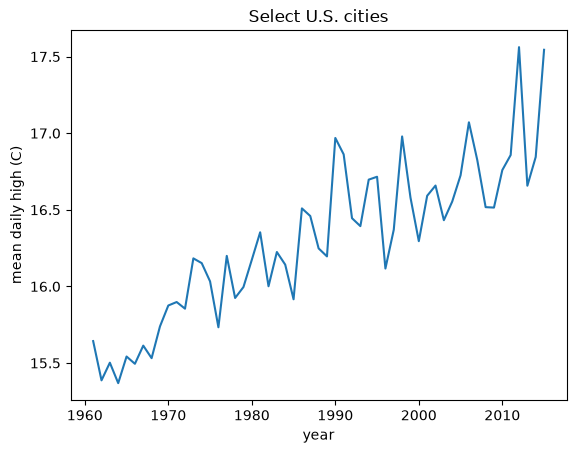

In [62]:
data = getTempData()
years = getYearlyMeans(data)
xVals, yVals = [], []
for e in years:
    xVals.append(e)
    yVals.append(years[e])

plt.plot(xVals, yVals)
plt.xlabel("year")
plt.ylabel("mean daily high (C)")
plt.title("Select U.S. cities")

In [69]:
def splitData(xVals, yVals):
    toTrain = random.sample(range(len(xVals)), len(xVals) // 2)

    trainX, trainY, testX, testY = [], [], [], []

    for i in range(len(xVals)):
        if i in toTrain:
            trainX.append(xVals[i])
            trainY.append(yVals[i])
        else:
            testX.append(xVals[i])
            testY.append(yVals[i])

    return trainX, trainY, testX, testY

In [70]:
numSubsets = 10
dimensions = (1, 2, 3, 4)
rSquares = {}

for d in dimensions:
    rSquares[d] = []

for f in range(numSubsets):
    trainX, trainY, testX, testY = splitData(xVals, yVals)

    for d in dimensions:
        model = np.polyfit(trainX, trainY, d)

        estYVals = np.polyval(model, testX)

        rSquares[d].append(rSquared(testY, estYVals))


print("Mean R-Squares for test Data")

for d in dimensions:
    mean = round(sum(rSquares[d]) / len(rSquares[d]), 4)
    sd = round(np.std(rSquares[d]), 4)

    print(f"For dimensionality {d} mean = {mean}, std = {sd}")

print(rSquares[1])

Mean R-Squares for test Data
For dimensionality 1 mean = 0.7346, std = 0.0509
For dimensionality 2 mean = 0.6817, std = 0.0583
For dimensionality 3 mean = 0.6769, std = 0.0522
For dimensionality 4 mean = 0.693, std = 0.0522
[np.float64(0.7211540856258902), np.float64(0.7435827676215031), np.float64(0.7903145537514902), np.float64(0.7792023858640164), np.float64(0.7963173917614619), np.float64(0.7385150164775174), np.float64(0.7563844798581678), np.float64(0.7082866222128856), np.float64(0.6958291518227141), np.float64(0.6161351837636864)]
